# Training Unimodal — EfficientNet B0/B1/B2
Training 12 experiments (3 backbones × 4 preprocessing modes) using K-Fold Cross Validation.

## Experiment grid
| Experiment | Model | Preprocessing |
|------------|-------|--------------|
| 01 | B0 | None |
| 02 | B0 | DullRazor |
| 03 | B0 | Color Constancy |
| 04 | B0 | Both |
| 05 | B1 | None |
| 06 | B1 | DullRazor |
| 07 | B1 | Color Constancy |
| 08 | B1 | Both |
| 09 | B2 | None |
| 10 | B2 | DullRazor |
| 11 | B2 | Color Constancy |
| 12 | B2 | Both |
| 13 | B3 | None |
| 14 | B3 | DullRazor |
| 15 | B3 | Color Constancy |
| 16 | B3 | Both |

In [1]:
import os
import sys
sys.path.append('../src')

import json
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

from config import METRICS_DIR, FIGURES_DIR, MODELS_DIR

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.dpi'] = 120
print('Imports OK')

Imports OK


## 1. GPU Check

In [2]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'VRAM available: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB reserved')
else:
    print('No GPU found, training will be slow on CPU.')

Device: cuda
GPU: NVIDIA GeForce RTX 2060
VRAM: 6.2 GB
VRAM available: 0.00 GB reserved


## 2. Launch Experiments
Run each experiment one by one. Each cell launches one experiment in the background.
Monitor progress with: `tail -f ../outputs/logs/<experiment>.log`

In [3]:
os.makedirs('../outputs/logs', exist_ok=True)

def launch_experiment(config_name):
    """Launch a single experiment in the background with nohup."""
    log_path    = f'../outputs/logs/{config_name}.log'
    config_path = f'../experiments/configs/{config_name}.yaml'
    cmd = f'nohup python ../src/../experiments/run.py --config {config_path} > {log_path} 2>&1 &'
    subprocess.Popen(cmd, shell=True, cwd='../src')
    print(f'Launched: {config_name}')
    print(f'Monitor: tail -f {log_path}')

def monitor_experiment(config_name):
    """Print last 20 lines of the experiment log."""
    log_path = f'../outputs/logs/{config_name}.log'
    if os.path.exists(log_path):
        with open(log_path, 'r') as f:
            lines = f.readlines()
        print(f'=== {config_name} (last 20 lines) ===')
        print(''.join(lines[-20:]))
    else:
        print(f'Log not found: {log_path}')

def is_finished(config_name):
    """Check if an experiment has finished."""
    log_path = f'../outputs/logs/{config_name}.log'
    if not os.path.exists(log_path):
        return False
    with open(log_path, 'r') as f:
        content = f.read()
    return 'K-Fold complete' in content

### Experiment 01 — B0 + None

In [6]:
launch_experiment('baseline_b0_none')

Launched: baseline_b0_none
Monitor: tail -f ../outputs/logs/baseline_b0_none.log


### Experiment 02 — B0 + DullRazor

In [7]:
launch_experiment('baseline_b0_dullrazor')

Launched: baseline_b0_dullrazor
Monitor: tail -f ../outputs/logs/baseline_b0_dullrazor.log


### Experiment 03 — B0 + Color Constancy

In [8]:
launch_experiment('baseline_b0_colorconstancy')

Launched: baseline_b0_colorconstancy
Monitor: tail -f ../outputs/logs/baseline_b0_colorconstancy.log


### Experiment 04 — B0 + Both

In [9]:
launch_experiment('baseline_b0_both')

Launched: baseline_b0_both
Monitor: tail -f ../outputs/logs/baseline_b0_both.log


### Experiment 05 — B1 + None

In [10]:
launch_experiment('baseline_b1_none')

Launched: baseline_b1_none
Monitor: tail -f ../outputs/logs/baseline_b1_none.log


### Experiment 06 — B1 + DullRazor

In [11]:
launch_experiment('baseline_b1_dullrazor')

Launched: baseline_b1_dullrazor
Monitor: tail -f ../outputs/logs/baseline_b1_dullrazor.log


### Experiment 07 — B1 + Color Constancy

In [6]:
launch_experiment('baseline_b1_colorconstancy')

Launched: baseline_b1_colorconstancy
Monitor: tail -f ../outputs/logs/baseline_b1_colorconstancy.log


### Experiment 08 — B1 + Both

In [7]:
launch_experiment('baseline_b1_both')

Launched: baseline_b1_both
Monitor: tail -f ../outputs/logs/baseline_b1_both.log


### Experiment 09 — B2 + None

In [4]:
launch_experiment('baseline_b2_none')

Launched: baseline_b2_none
Monitor: tail -f ../outputs/logs/baseline_b2_none.log


### Experiment 10 — B2 + DullRazor

In [ ]:
launch_experiment('baseline_b2_dullrazor')

### Experiment 11 — B2 + Color Constancy

In [4]:
launch_experiment('baseline_b2_colorconstancy')

Launched: baseline_b2_colorconstancy
Monitor: tail -f ../outputs/logs/baseline_b2_colorconstancy.log


### Experiment 12 — B2 + Both

In [5]:
launch_experiment('baseline_b2_both')

Launched: baseline_b2_both
Monitor: tail -f ../outputs/logs/baseline_b2_both.log


### Experiment 13 — B3 + None

In [6]:
launch_experiment('baseline_b3_none')

Launched: baseline_b3_none
Monitor: tail -f ../outputs/logs/baseline_b3_none.log


### Experiment 14 — B3 + DullRazor

In [ ]:
launch_experiment('baseline_b3_dullrazor')

### Experiment 15 — B3 + ColorConstancy

In [ ]:
launch_experiment('baseline_b3_colorconstancy')

### Experiment 16 — B3 + Both

In [ ]:
launch_experiment('baseline_b3_both')

## 3. Results Comparison — All Experiments

In [5]:
# Load all summaries
summary_files = glob(os.path.join(METRICS_DIR, '*_summary.csv'))
summaries = []
for f in summary_files:
    df_s = pd.read_csv(f)
    summaries.append(df_s)

results_df = pd.concat(summaries, ignore_index=True)
results_df = results_df.dropna(subset=['experiment'])
results_df = results_df.sort_values('mean_auc', ascending=False).reset_index(drop=True)
results_df['rank'] = results_df.index + 1
print(f'Total experiments: {len(results_df)}')
results_df[['rank', 'experiment', 'model', 'preprocessing', 'mean_auc', 'std_auc']]

Total experiments: 16


,rank,experiment,model,preprocessing,mean_auc,std_auc
0,1,efficientnet_b0_none,b0,none,0.959342,0.002812
1,2,efficientnet_b3_none,b3,none,0.958763,0.004664
2,3,efficientnet_b2_none,b2,none,0.956990,0.003028
3,4,efficientnet_b2_colorconstancy,b2,colorconstancy,0.955234,0.004247
4,5,efficientnet_b0_colorconstancy,b0,colorconstancy,0.954511,0.005098
5,6,efficientnet_b1_none,b1,none,0.953402,0.007926
6,7,efficientnet_b3_dullrazor,b3,dullrazor,0.953178,0.003156
7,8,efficientnet_b3_colorconstancy,b3,colorconstancy,0.953162,0.004273
8,9,efficientnet_b0_dullrazor,b0,dullrazor,0.952004,0.005063
9,10,efficientnet_b0_both,b0,both,0.951092,0.004567


### 3.1 AUC Ranking — All Experiments

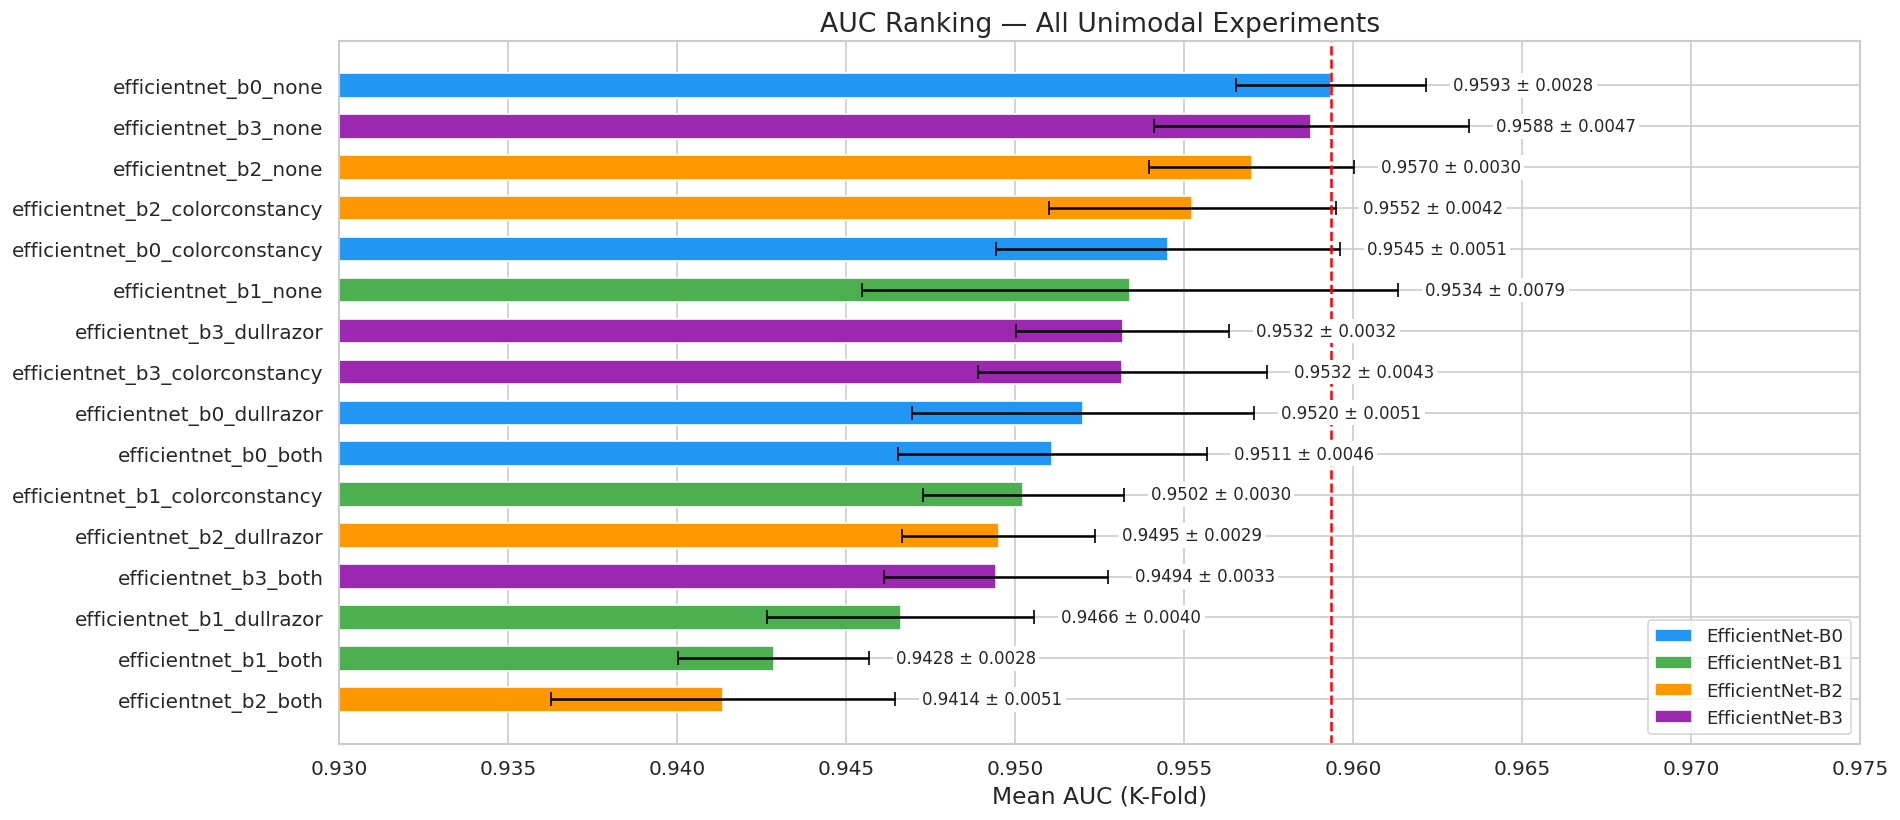

In [6]:
fig, ax = plt.subplots(figsize=(16, 7))

colors_map = {'b0': '#2196F3', 'b1': '#4CAF50', 'b2': '#FF9800', 'b3': '#9C27B0'}
bar_colors = [colors_map[m] for m in results_df['model']]

bars = ax.barh(
    results_df['experiment'][::-1],
    results_df['mean_auc'][::-1],
    xerr=results_df['std_auc'][::-1],
    color=bar_colors[::-1],
    edgecolor='white',
    capsize=4,
    height=0.6
)

ax.set_xlabel('Mean AUC (K-Fold)', fontsize=14)
ax.set_title('AUC Ranking — All Unimodal Experiments', fontsize=16)
ax.tick_params(axis='both', labelsize=12)
ax.set_xlim(0.93, 0.975)
ax.axvline(results_df['mean_auc'].max(), color='red', linestyle='--',
           linewidth=1.5, label=f'Best: {results_df["mean_auc"].max():.4f}')

for bar, auc, std in zip(bars, results_df['mean_auc'][::-1], results_df['std_auc'][::-1]):
    x_pos = auc + std + 0.0008
    ax.text(x_pos, bar.get_y() + bar.get_height()/2,
            f'{auc:.4f} ± {std:.4f}', va='center', fontsize=10,
            bbox=dict(facecolor='white', edgecolor='none', pad=2))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'EfficientNet-{m.upper()}')
                   for m, c in colors_map.items()]
ax.legend(handles=legend_elements, fontsize=11, loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'unimodal_auc_ranking.png'), bbox_inches='tight', dpi=150)
plt.show()

### 3.2 AUC Heatmap — Backbone vs Preprocessing

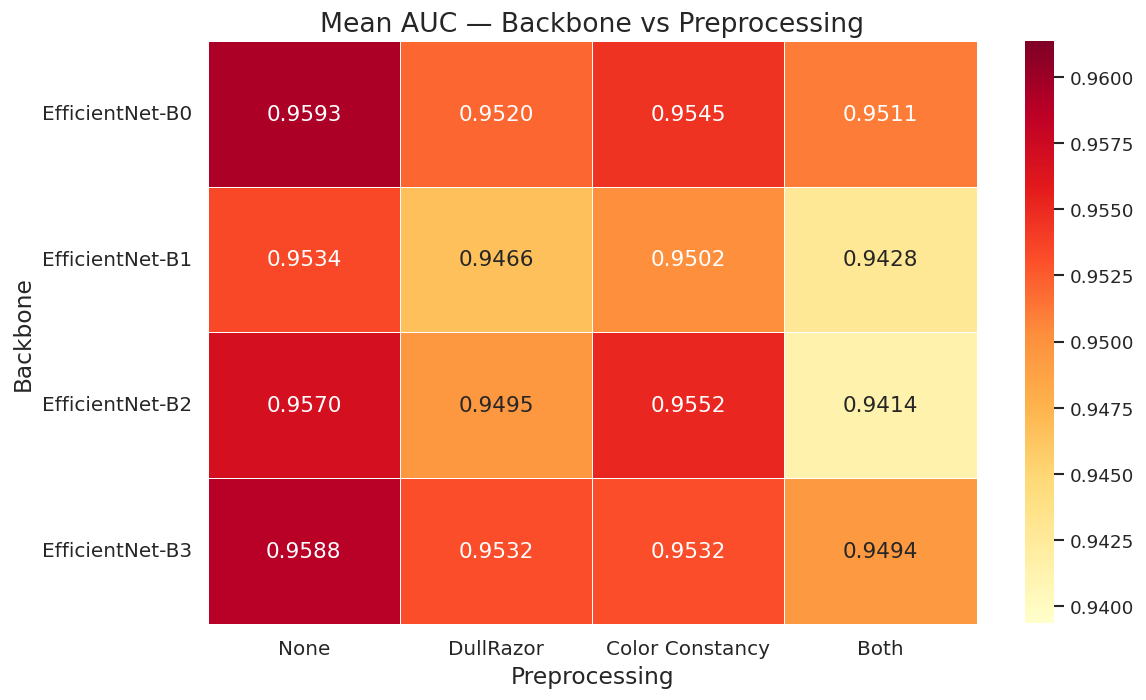

In [7]:
heatmap_data = results_df.pivot(index='model', columns='preprocessing', values='mean_auc')
heatmap_data = heatmap_data.loc[['b0', 'b1', 'b2', 'b3'],
                                 ['none', 'dullrazor', 'colorconstancy', 'both']]

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    heatmap_data, annot=True, fmt='.4f',
    cmap='YlOrRd', ax=ax,
    annot_kws={'size': 13},
    linewidths=0.5, linecolor='white',
    vmin=heatmap_data.values.min() - 0.002,
    vmax=heatmap_data.values.max() + 0.002
)
ax.set_title('Mean AUC — Backbone vs Preprocessing', fontsize=16)
ax.set_xlabel('Preprocessing', fontsize=14)
ax.set_ylabel('Backbone', fontsize=14)
ax.set_yticklabels(['EfficientNet-B0', 'EfficientNet-B1', 'EfficientNet-B2', 'EfficientNet-B3'],
                    rotation=0, fontsize=12)
ax.set_xticklabels(['None', 'DullRazor', 'Color Constancy', 'Both'],
                    rotation=0, fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'unimodal_auc_heatmap.png'), bbox_inches='tight', dpi=150)
plt.show()

### 3.3 AUC by Backbone

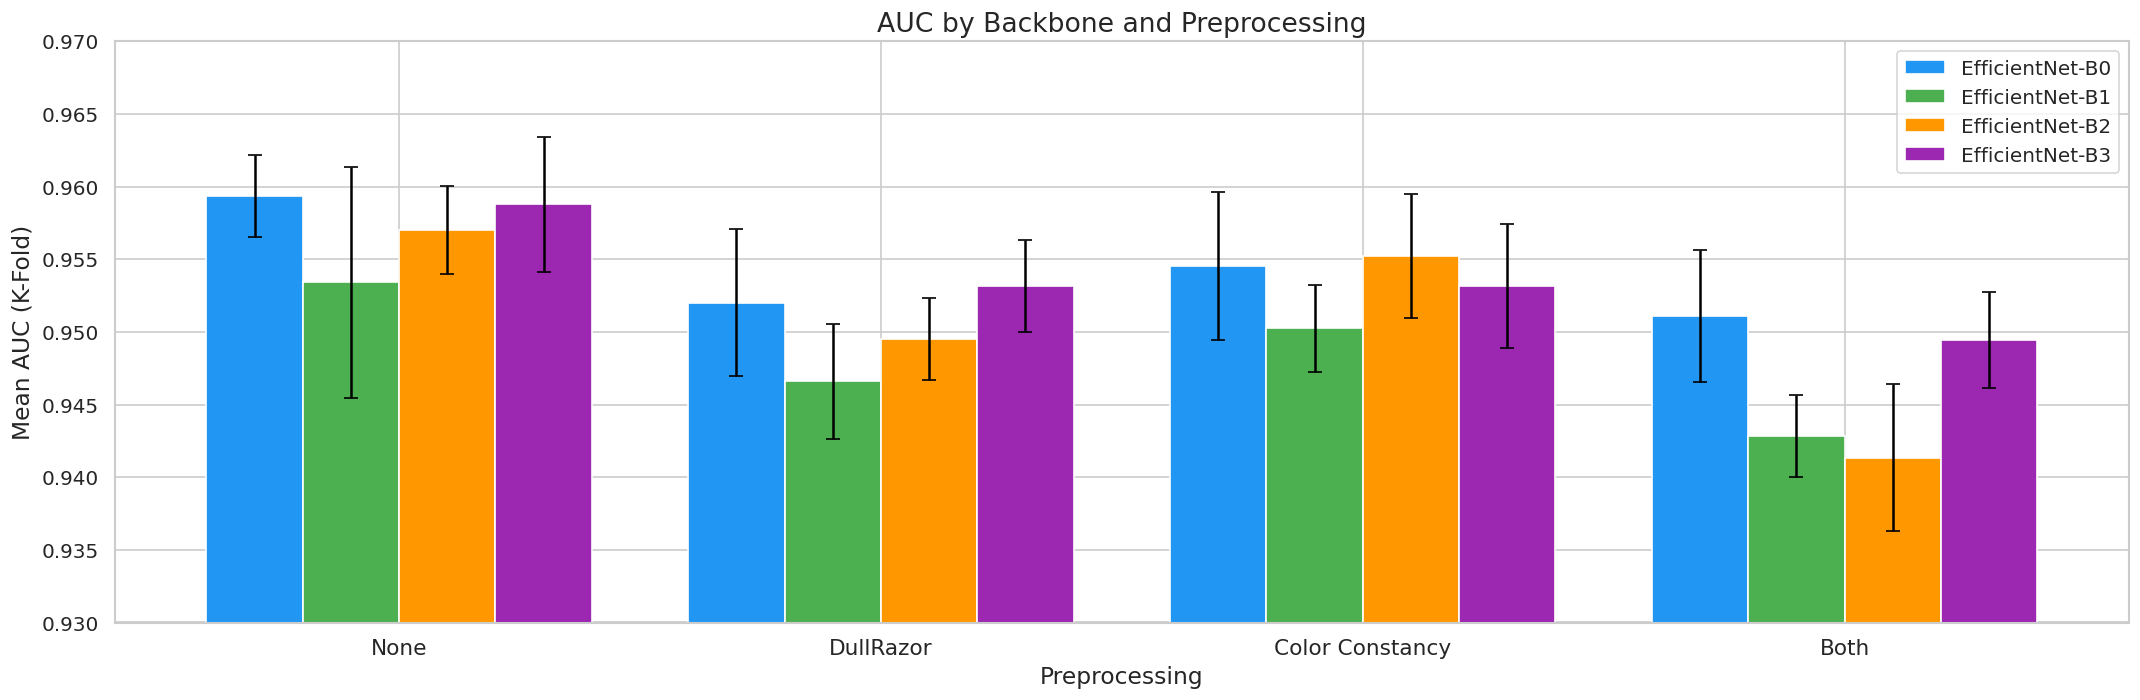

In [13]:
preprocess_order = ['none', 'dullrazor', 'colorconstancy', 'both']
preprocess_labels = ['None', 'DullRazor', 'Color Constancy', 'Both']
backbone_colors = {'b0': '#2196F3', 'b1': '#4CAF50', 'b2': '#FF9800', 'b3': '#9C27B0'}

x = np.arange(len(preprocess_order))
width = 0.2

fig, ax = plt.subplots(figsize=(18, 6))

for i, (backbone, color) in enumerate(backbone_colors.items()):
    aucs = [results_df[(results_df['model'] == backbone) &
                        (results_df['preprocessing'] == p)]['mean_auc'].values[0]
            for p in preprocess_order]
    stds = [results_df[(results_df['model'] == backbone) &
                        (results_df['preprocessing'] == p)]['std_auc'].values[0]
            for p in preprocess_order]
    bars = ax.bar(x + i * width, aucs, width, yerr=stds,
                  label=f'EfficientNet-{backbone.upper()}',
                  color=color, edgecolor='white', capsize=4)

ax.set_xlabel('Preprocessing', fontsize=14)
ax.set_ylabel('Mean AUC (K-Fold)', fontsize=14)
ax.set_title('AUC by Backbone and Preprocessing', fontsize=16)
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(preprocess_labels, fontsize=13)
ax.tick_params(axis='y', labelsize=12)
ax.set_ylim(0.93, 0.97)
ax.legend(fontsize=12)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'unimodal_auc_by_backbone.png'), bbox_inches='tight', dpi=150)
plt.show()

### 3.4 Results Summary Table

In [14]:
summary_table = results_df[['rank', 'experiment', 'model', 'preprocessing', 'mean_auc', 'std_auc']].copy()
summary_table['model']         = summary_table['model'].str.upper()
summary_table['preprocessing'] = summary_table['preprocessing'].str.replace('colorconstancy', 'Color Constancy').str.replace('dullrazor', 'DullRazor').str.replace('none', 'None').str.replace('both', 'Both')
summary_table['mean_auc']      = summary_table['mean_auc'].round(4)
summary_table['std_auc']       = summary_table['std_auc'].round(4)
summary_table.columns         = ['Rank', 'Experiment', 'Backbone', 'Preprocessing', 'Mean AUC', 'Std AUC']

# Save to CSV
summary_table.to_csv(os.path.join(METRICS_DIR, 'unimodal_results_summary.csv'), index=False)

print('=== Unimodal Results Summary ===\n')
print(summary_table.to_string(index=False))
print(f'\nBest experiment: {summary_table.iloc[0]["Experiment"]}')
print(f'Best Mean AUC:   {summary_table.iloc[0]["Mean AUC"]}')

=== Unimodal Results Summary ===

 Rank                     Experiment Backbone   Preprocessing  Mean AUC  Std AUC
    1           efficientnet_b0_none       B0            None    0.9593   0.0028
    2           efficientnet_b3_none       B3            None    0.9588   0.0047
    3           efficientnet_b2_none       B2            None    0.9570   0.0030
    4 efficientnet_b2_colorconstancy       B2 Color Constancy    0.9552   0.0042
    5 efficientnet_b0_colorconstancy       B0 Color Constancy    0.9545   0.0051
    6           efficientnet_b1_none       B1            None    0.9534   0.0079
    7      efficientnet_b3_dullrazor       B3       DullRazor    0.9532   0.0032
    8 efficientnet_b3_colorconstancy       B3 Color Constancy    0.9532   0.0043
    9      efficientnet_b0_dullrazor       B0       DullRazor    0.9520   0.0051
   10           efficientnet_b0_both       B0            Both    0.9511   0.0046
   11 efficientnet_b1_colorconstancy       B1 Color Constancy    0.9502   0

## 4. Learning Curves
Train loss vs Val AUC per fold for each experiment.

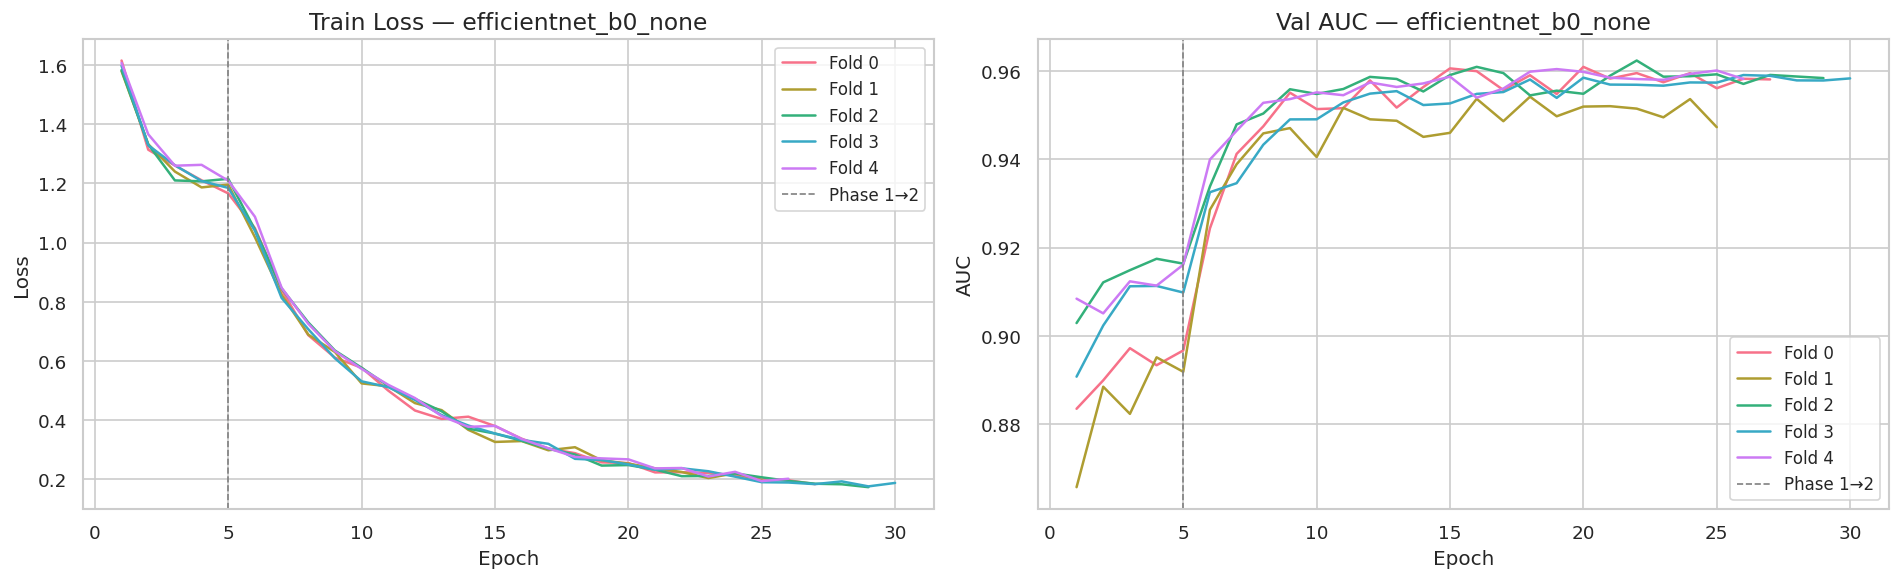

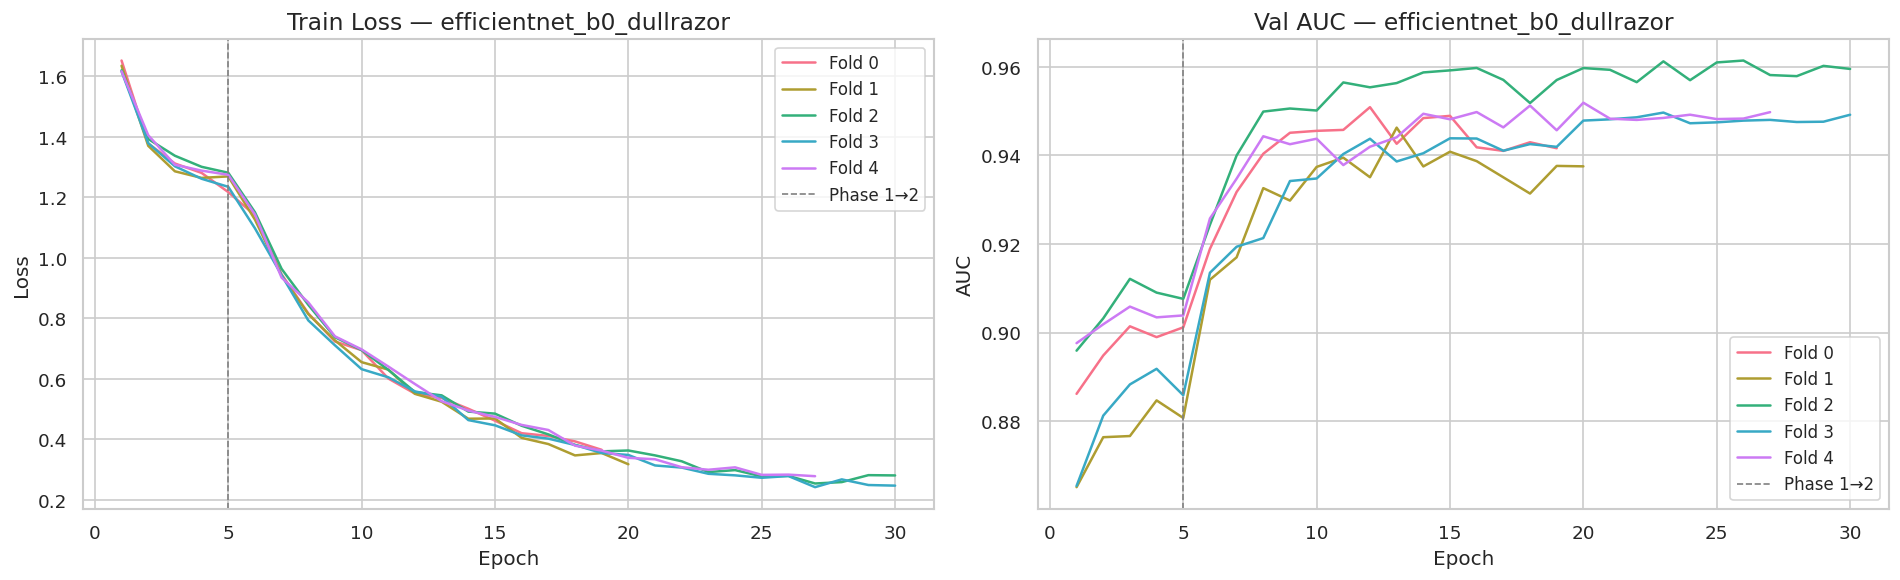

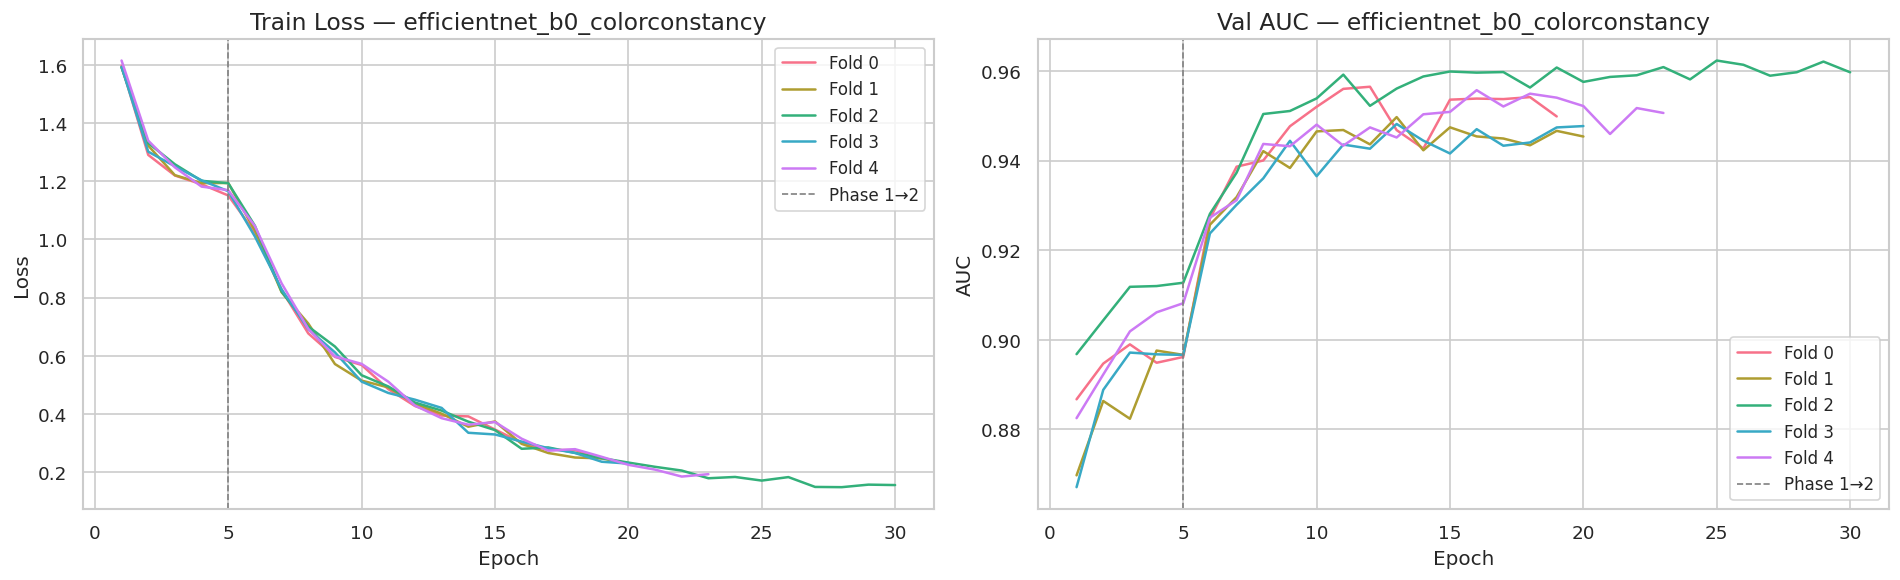

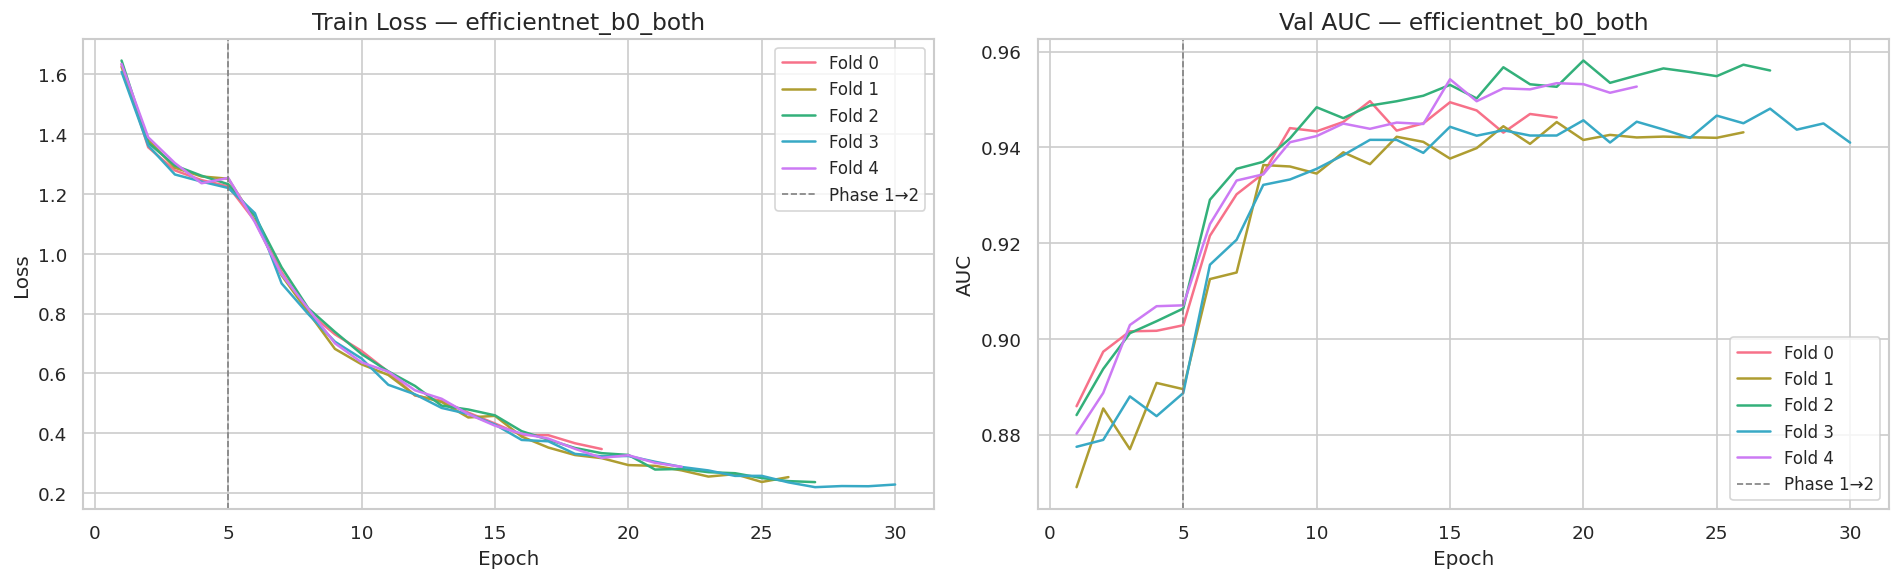

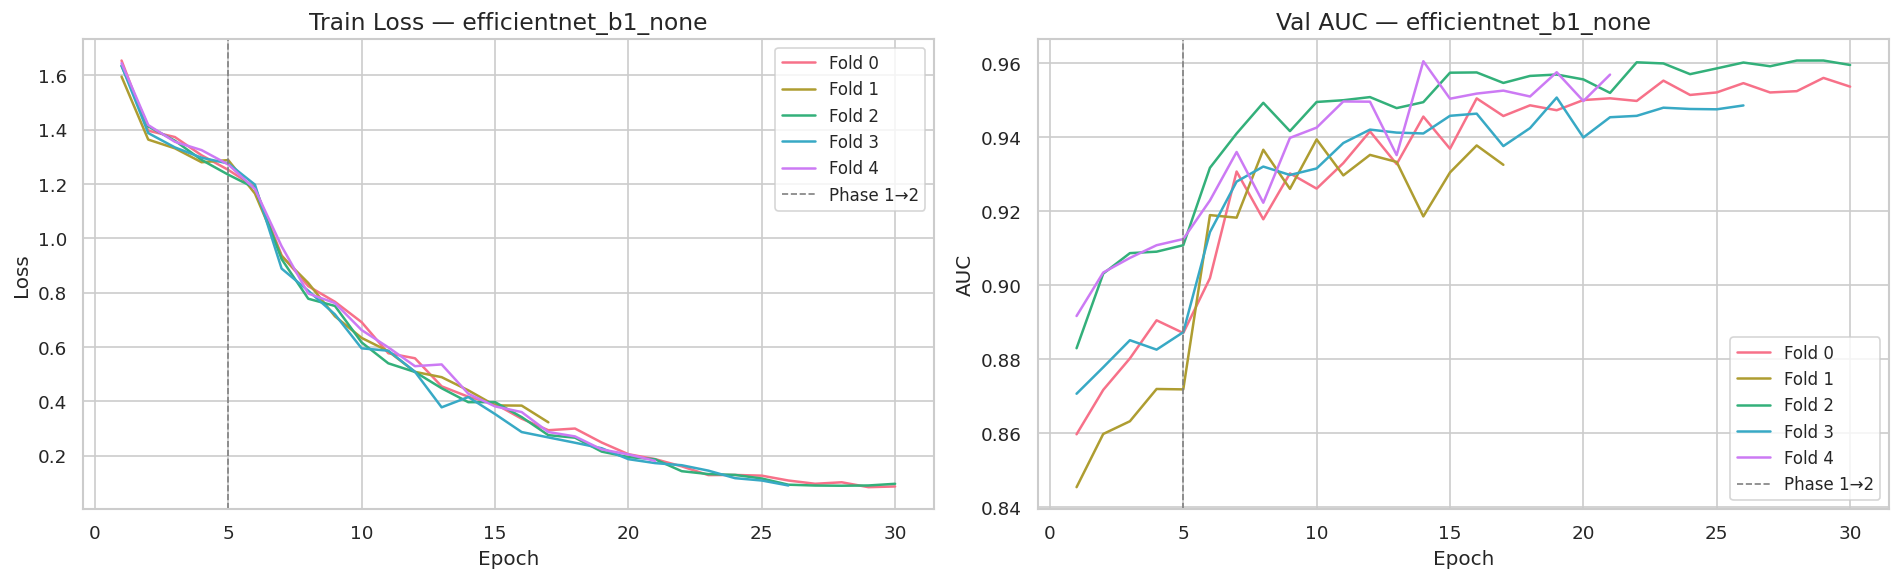

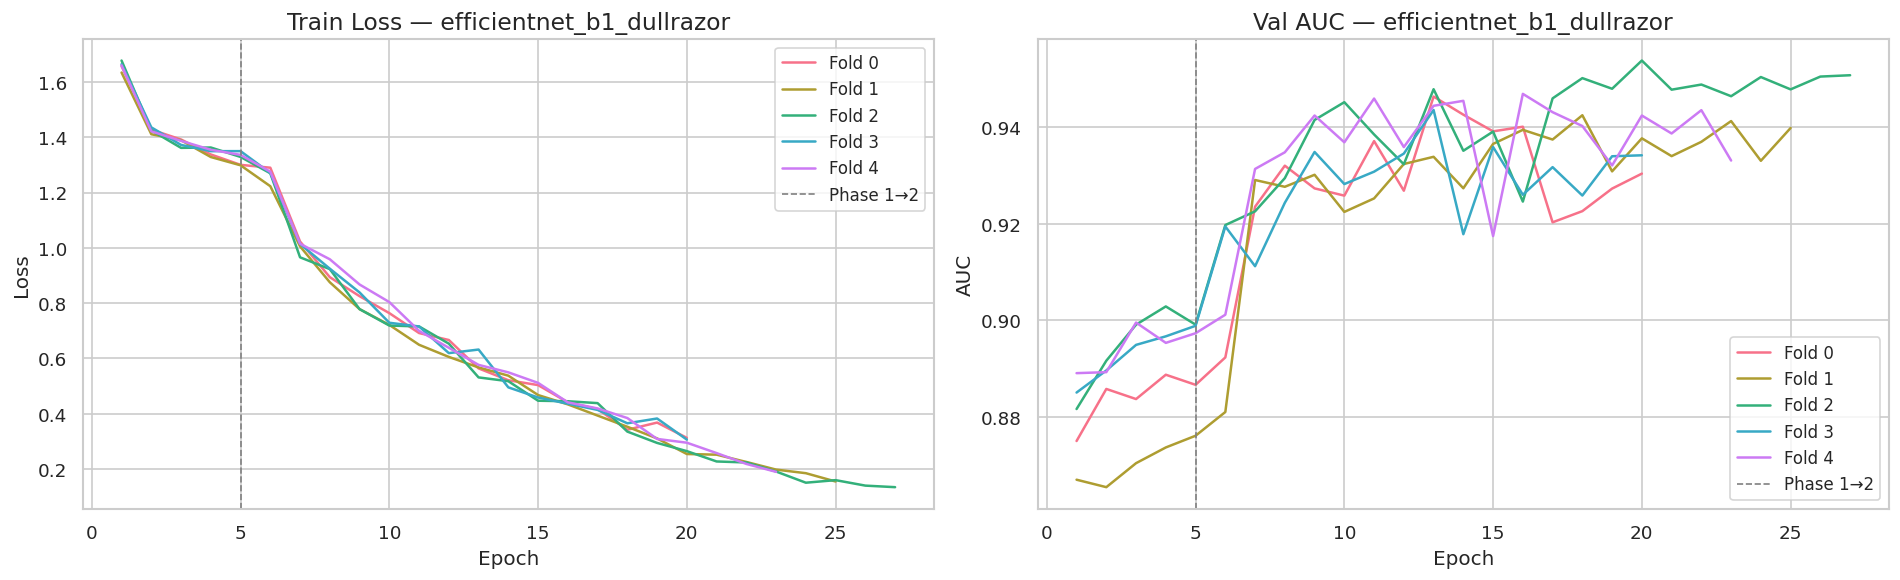

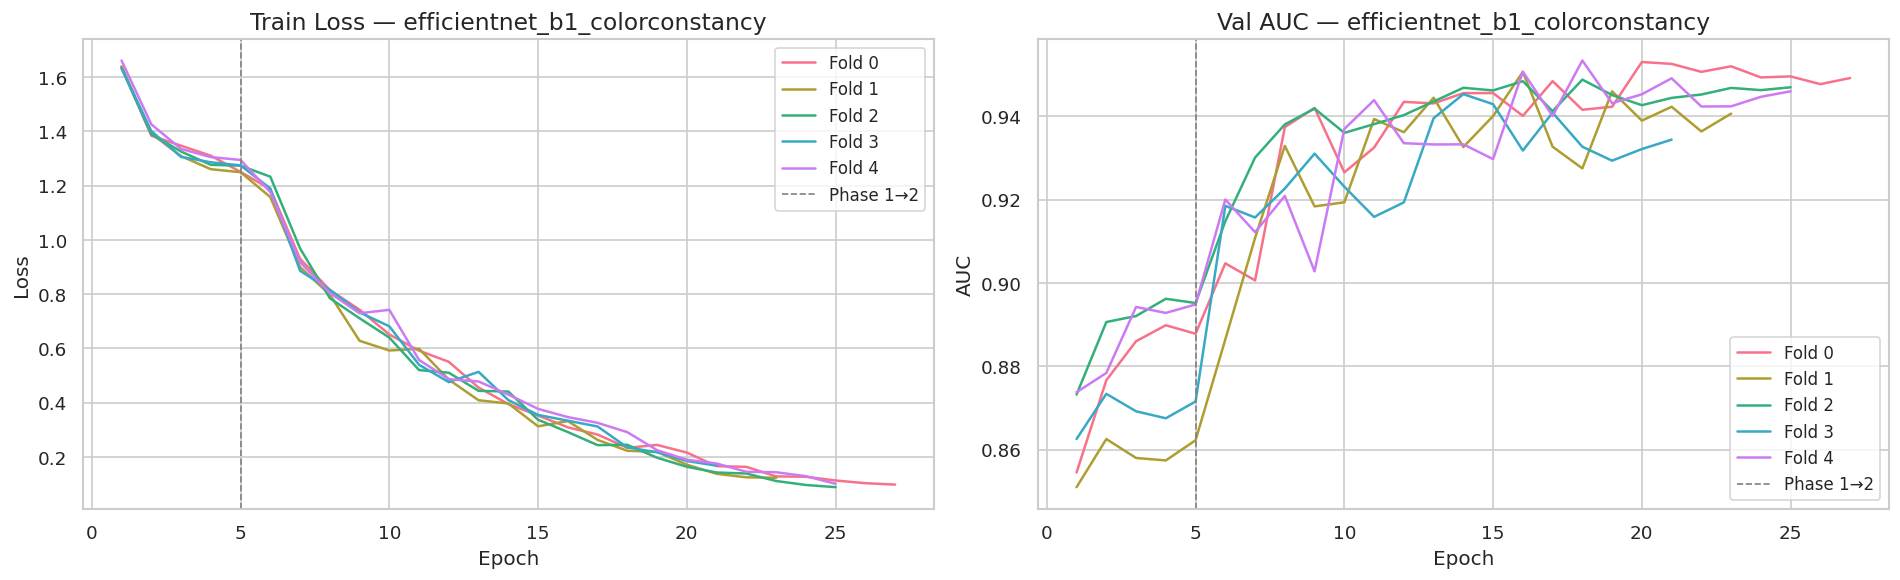

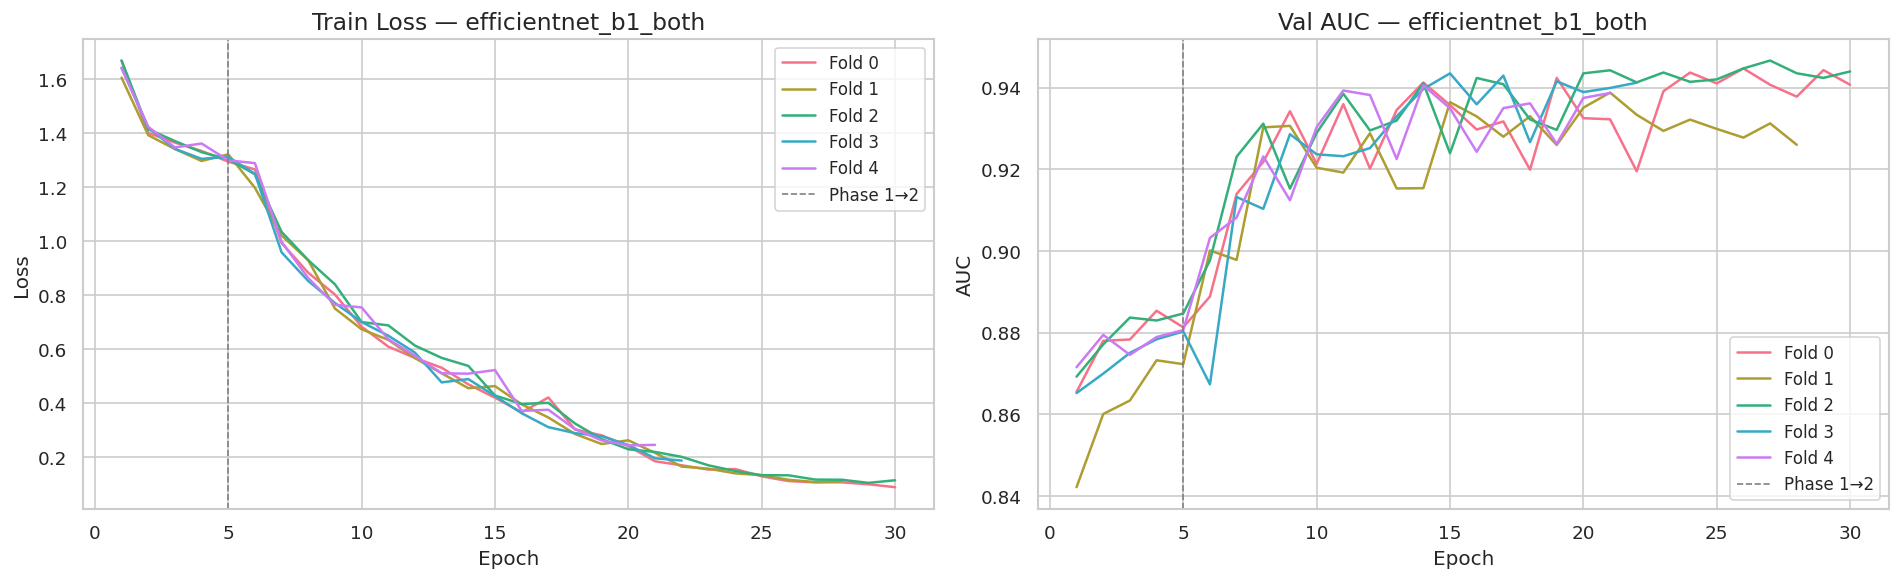

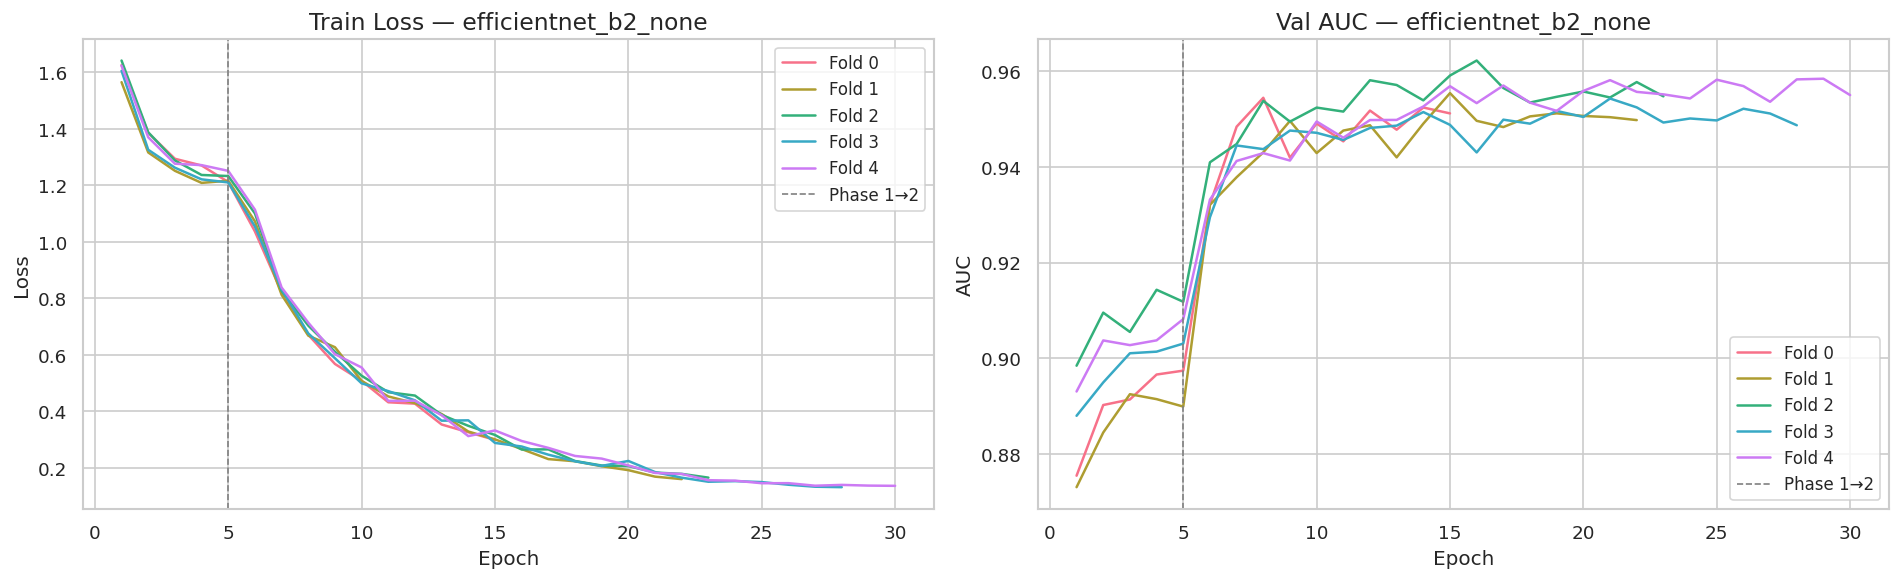

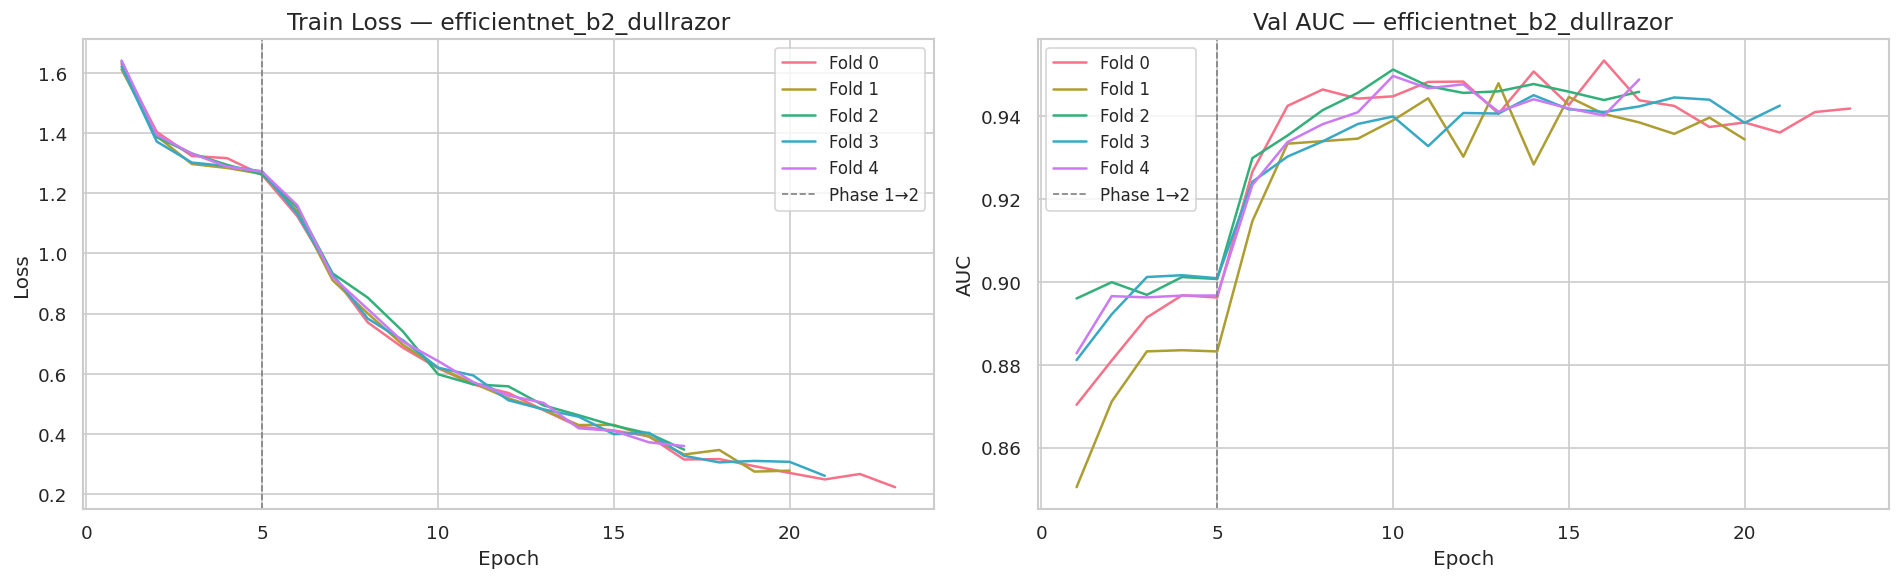

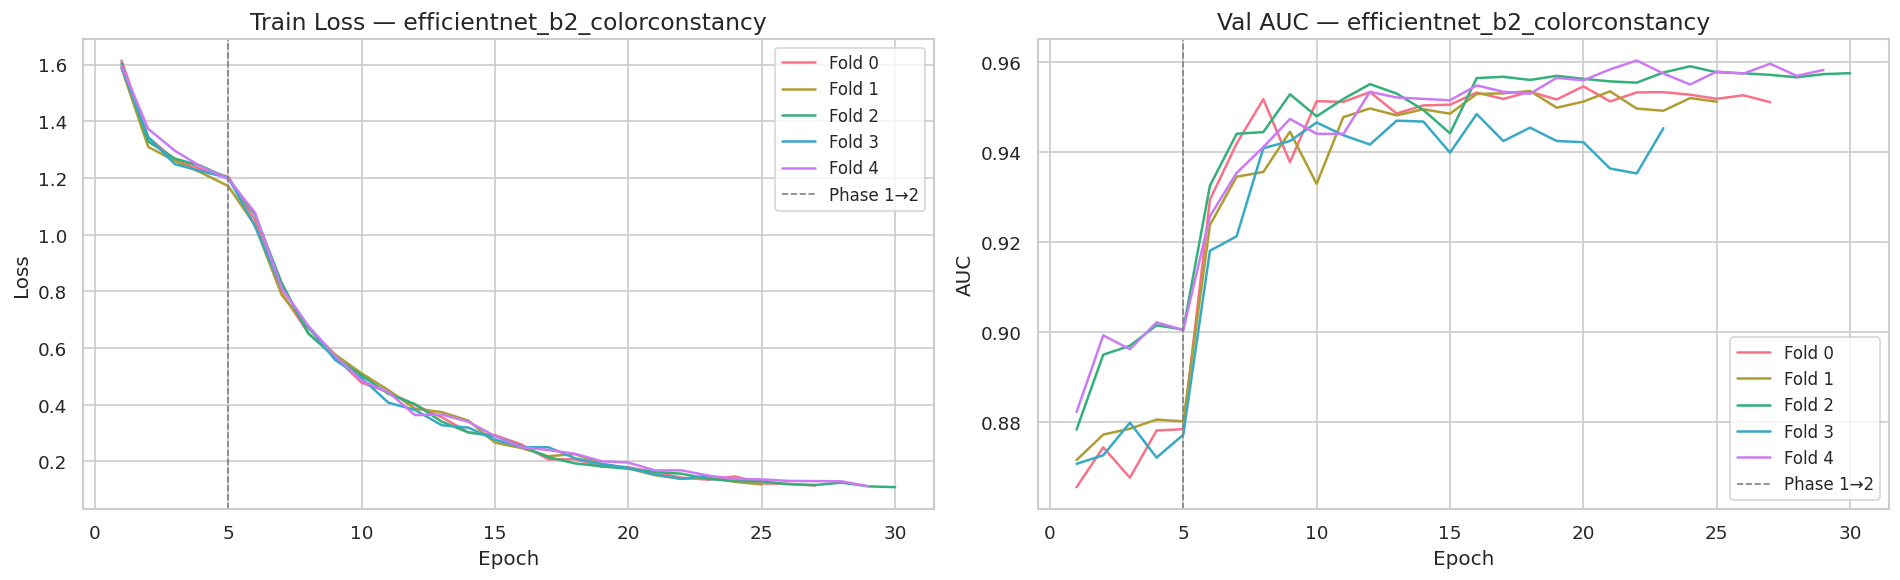

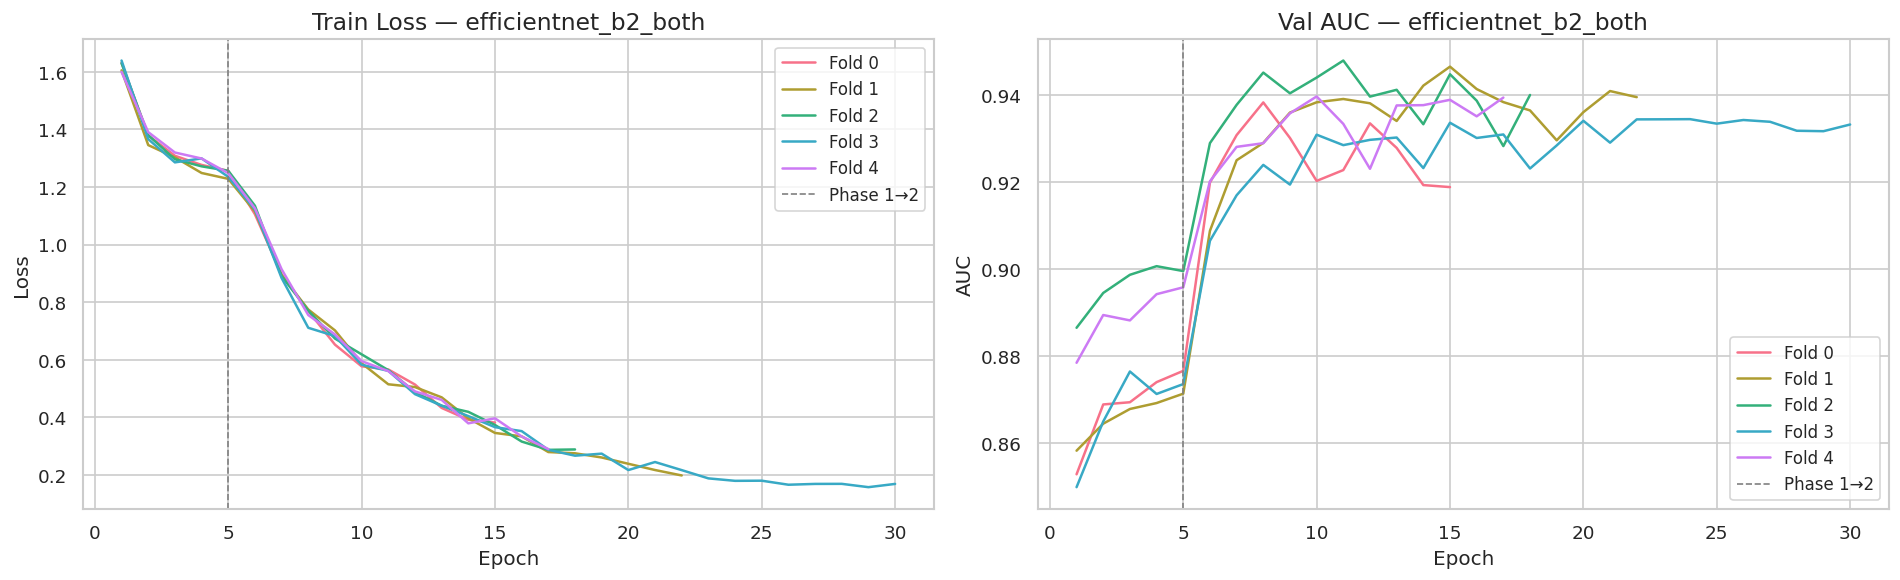

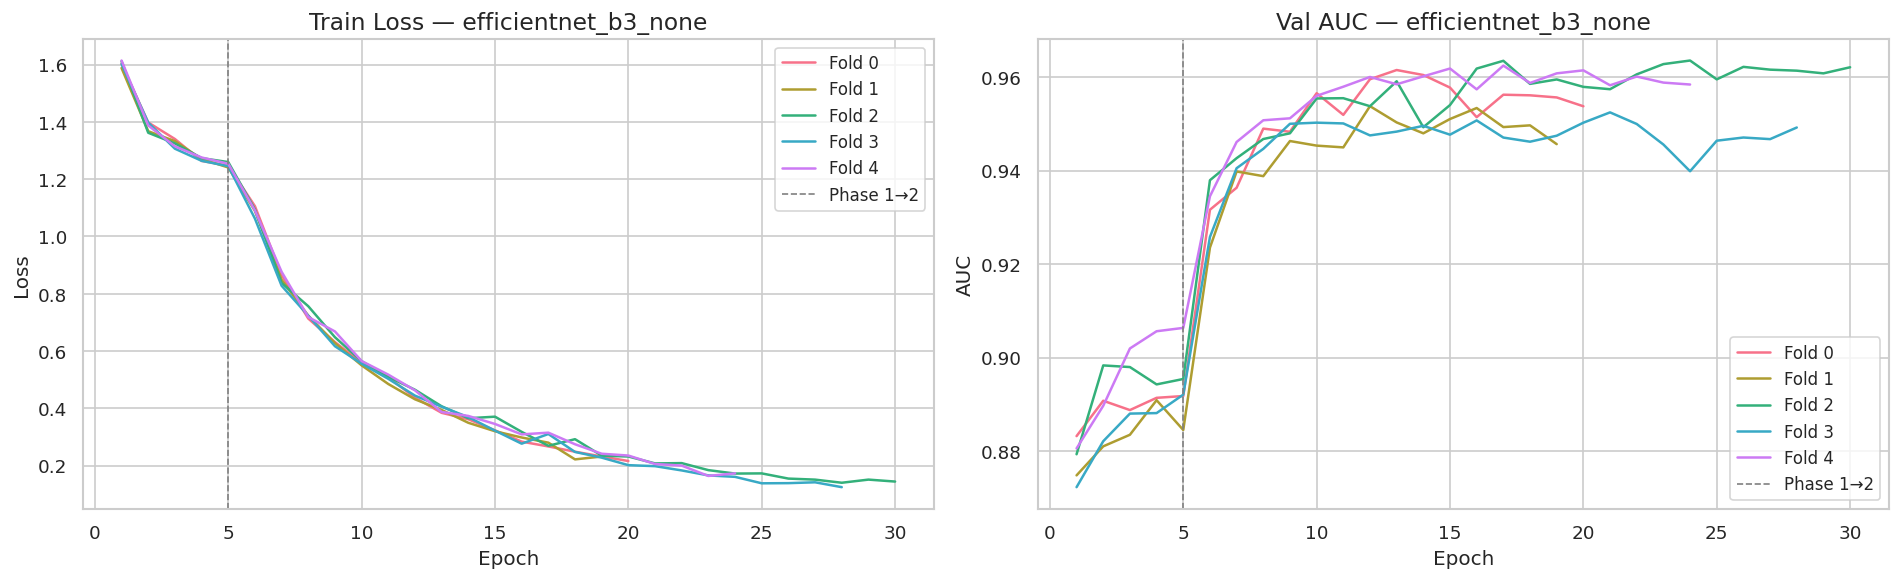

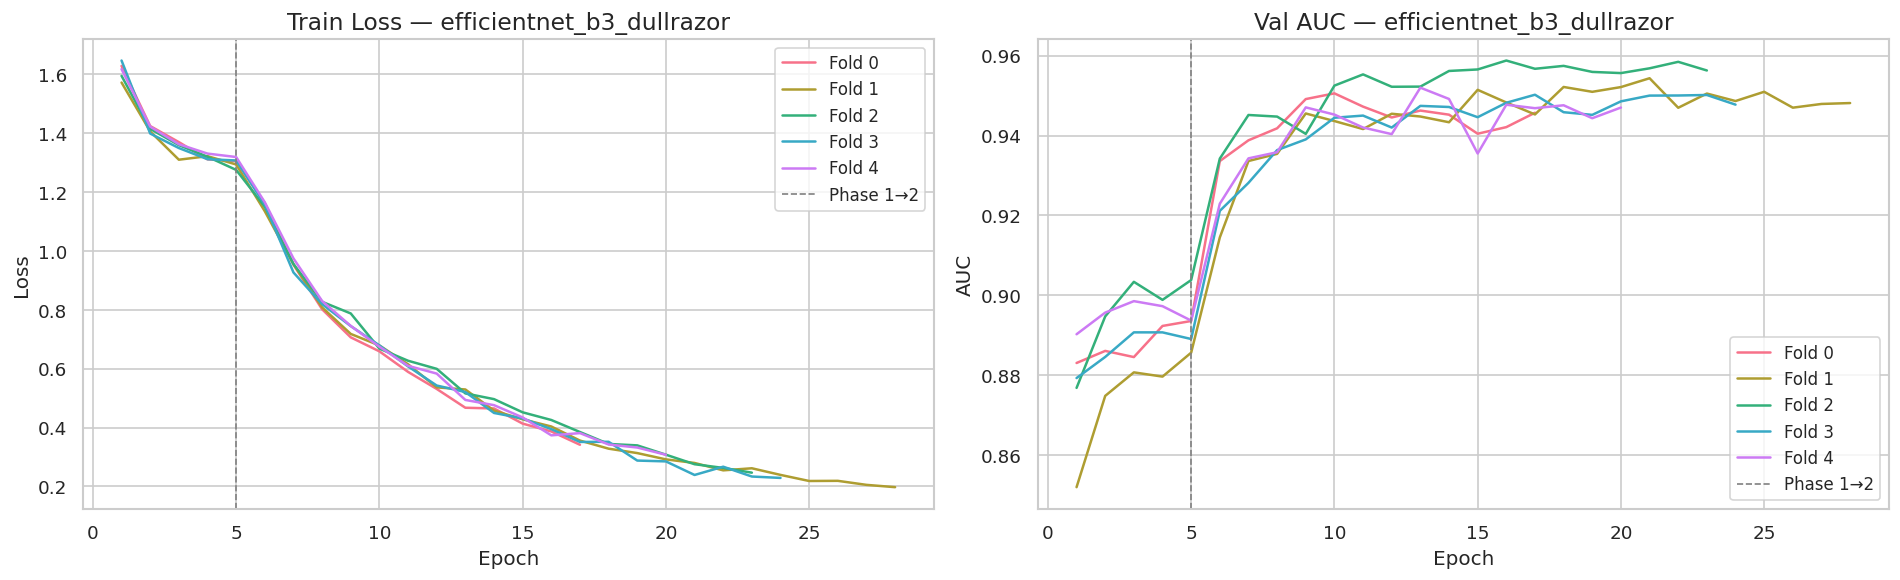

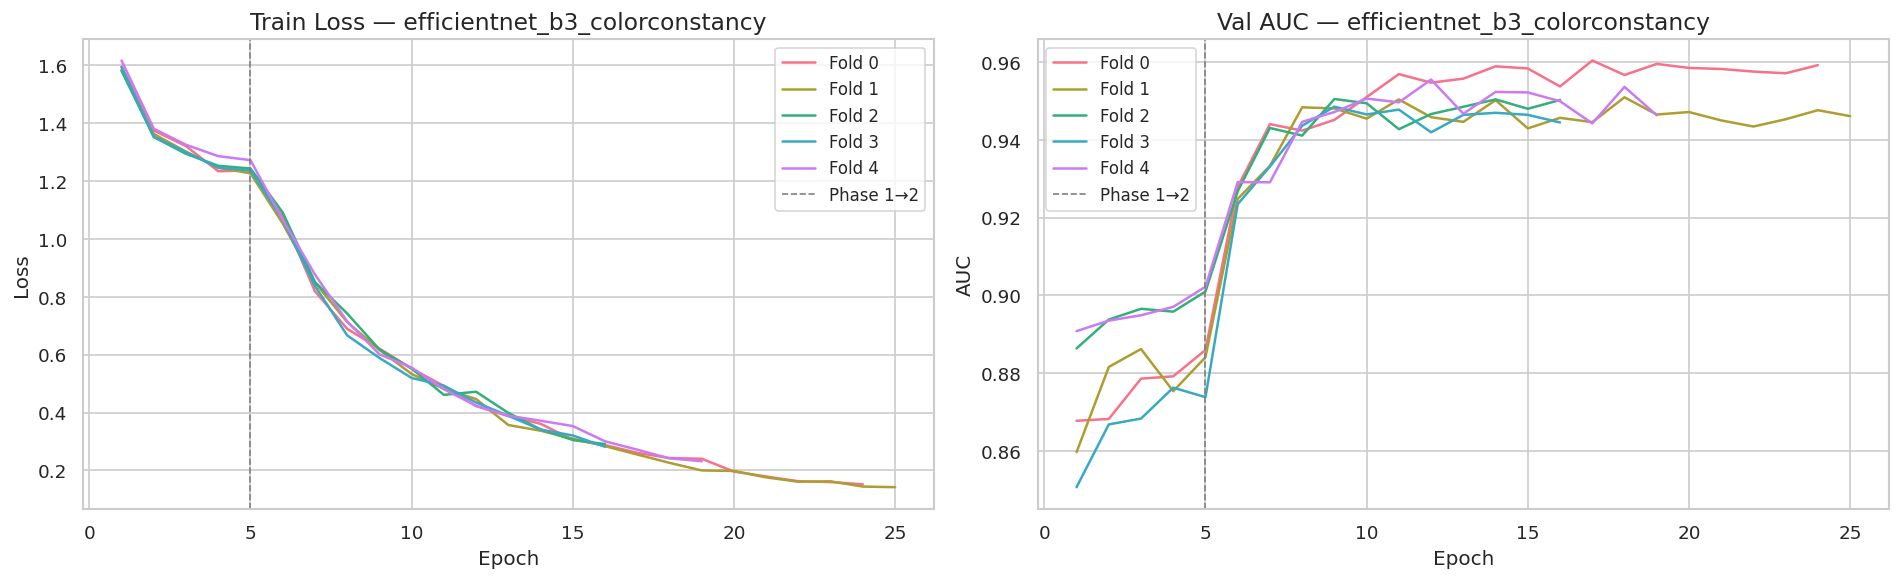

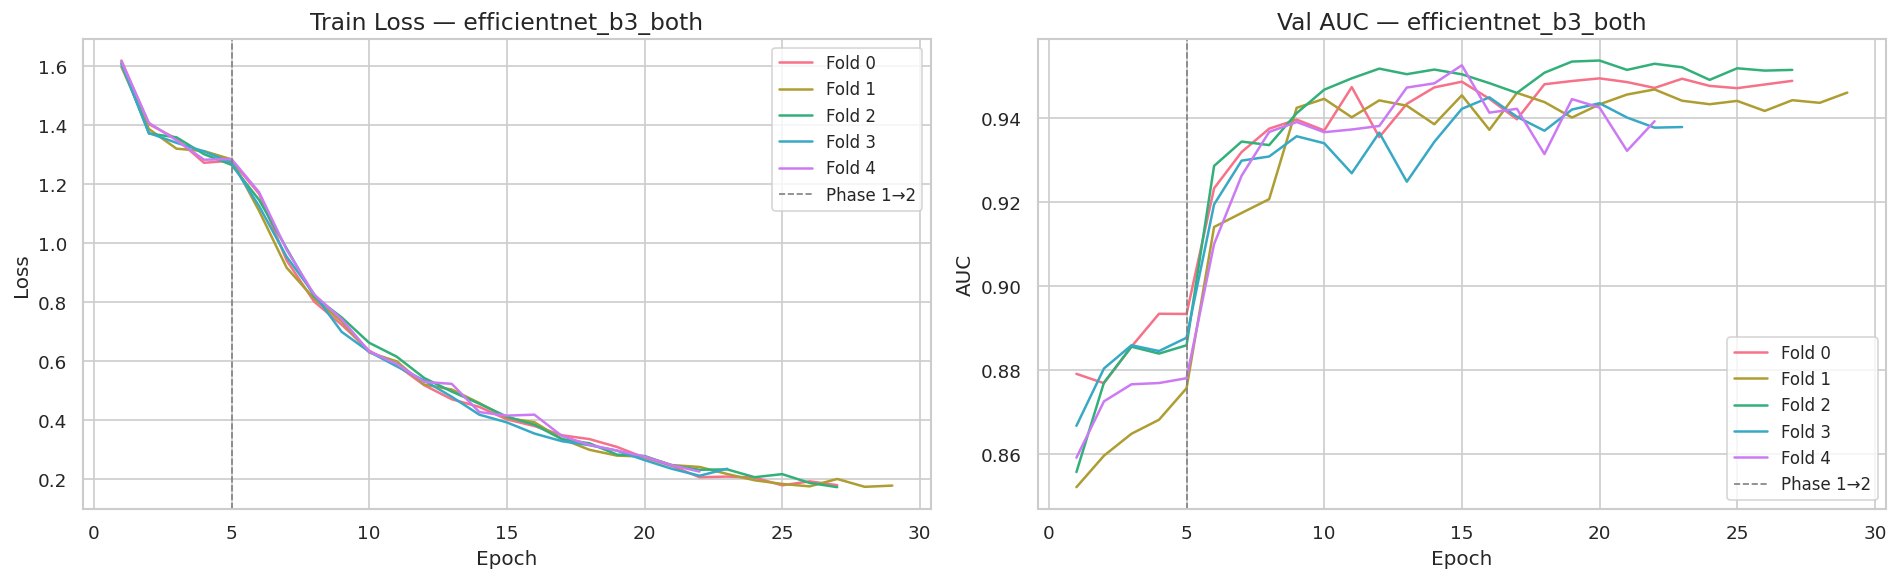

In [15]:
def plot_learning_curves(experiment_name):
    """Plot train loss and val AUC per epoch for all folds."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = sns.color_palette('husl', 5)

    for fold in range(5):
        history_path = os.path.join(METRICS_DIR, f'{experiment_name}_fold{fold}_history.csv')
        if not os.path.exists(history_path):
            print(f'Missing: {history_path}')
            continue
        df_h = pd.read_csv(history_path)

        axes[0].plot(df_h['epoch'], df_h['train_loss'],
                     color=colors[fold], label=f'Fold {fold}', linewidth=1.5)
        axes[1].plot(df_h['epoch'], df_h['val_auc'],
                     color=colors[fold], label=f'Fold {fold}', linewidth=1.5)

    # Phase boundary
    for ax in axes:
        ax.axvline(5, color='gray', linestyle='--', linewidth=1,
                   label='Phase 1→2')
        ax.legend(fontsize=10)
        ax.tick_params(axis='both', labelsize=11)

    axes[0].set_title(f'Train Loss — {experiment_name}', fontsize=14)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)

    axes[1].set_title(f'Val AUC — {experiment_name}', fontsize=14)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('AUC', fontsize=12)

    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'learning_curves_{experiment_name}.png'),
                bbox_inches='tight', dpi=150)
    plt.show()

# Plot for all experiments
experiments_names = [
    'efficientnet_b0_none', 'efficientnet_b0_dullrazor',
    'efficientnet_b0_colorconstancy', 'efficientnet_b0_both',
    'efficientnet_b1_none', 'efficientnet_b1_dullrazor',
    'efficientnet_b1_colorconstancy', 'efficientnet_b1_both',
    'efficientnet_b2_none', 'efficientnet_b2_dullrazor',
    'efficientnet_b2_colorconstancy', 'efficientnet_b2_both',
    'efficientnet_b3_none', 'efficientnet_b3_dullrazor',
    'efficientnet_b3_colorconstancy', 'efficientnet_b3_both',
]

for exp in experiments_names:
    plot_learning_curves(exp)

No hay overfitting en ningún modelo ✅
- El train loss baja de forma suave y consistente en todos
- El val AUC sube y se estabiliza, no baja → no hay divergencia train/val


B0 es el más estable:
- Las 5 curvas de loss están casi pegadas → muy poca varianza entre folds
- Val AUC converge rápido (~época 10) y se mantiene estable


B1 es el más inestable:
- Val AUC tiene más oscilaciones en fase 2
- Más varianza entre folds → confirma el std alto que vimos (0.0079)


B2 tiene un comportamiento interesante:
- Train loss baja más que B0 y B1 → aprende más agresivamente
- Pero val AUC no mejora proporcionalmente → señal de que empieza a memorizar más que generalizar, aunque sin llegar a overfitting claro


Conclusión:
- B0 → más estable y generaliza mejor
- B1 → más ruidoso, menos fiable
- B2 → aprende más pero no generaliza mejor

B3 destacable:
- B3 none → curvas muy estables, train loss baja suave, val AUC converge bien. Muy similar a B0 visualmente
- B3 colorconstancy → curiosamente el val AUC tiene menos varianza entre folds que B0 colorconstancy, los folds están más juntos
- B3 dullrazor → también estable, mejor que B1/B2 dullrazor
- B3 both → más varianza entre folds, fold 3 se queda atrás

Comparando con B0:
- B0 none sigue siendo el más estable de todos, curvas casi pegadas
- B3 none es muy parecido pero con algo más de varianza entre folds (confirma el std 0.0047 vs 0.0028 de B0)